In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

### Import the training data

In [3]:
data = np.load("menu-match.npz")

# The training data is a 480 × 48 × 48 × 3 tensor, 
# meaning 480 images, each image is 48 × 48 pixels, with 3 color channels (RGB).

##### In short, y is the label ('a', 'i', 's')
##### In short, x is the image for food

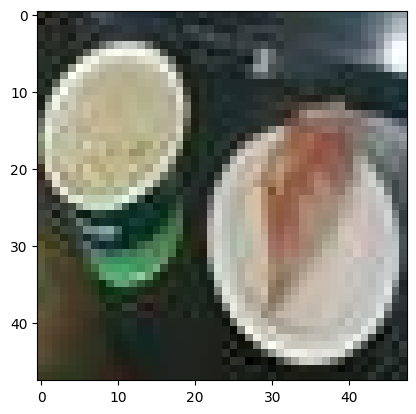

In [4]:
plt.imshow(data['X_test'][30])

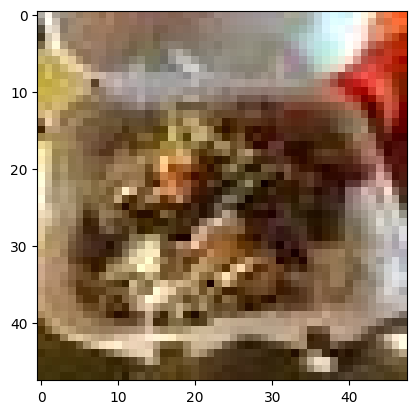

In [5]:
plt.imshow(data['X_train'][30])

In [6]:
data['X_train'].shape
# 480 training images, each 48×48 pixels with 3 RGB channels.

(480, 48, 48, 3)

In [7]:
data['X_test'].shape
# 166 test images, each 48×48 pixels with 3 RGB channels.

(166, 48, 48, 3)

In [8]:
data['y_train'].shape
# 480 training labels, one label per training image.

(480,)

In [9]:
data['y_test'].shape

(166,)

In [10]:
data['y_test'][0]

np.str_('a')

### Dataloader --> shuffle and then split into mini-batches
### train on small chunks instead of all 480 at once 

In [11]:
# 1) load data
data = np.load("menu-match.npz")
X = data["X_train"]   
y = data["y_train"]
X_TEST = data['X_test']
Y_TEST = data['y_test']

# data['X_train'].shape is (480, 48, 48, 3)

# 2) convert to torch + fix shape to channels-first for CNN
# converts NumPy → float tensor and reoder axes from NHWC to NCHW
# make it ready to put into 'Conv2d'(the learning layer). It needs num of image, channels, hieght width
X_t = torch.tensor(X).float().permute(0, 3, 1, 2)
X_test_t = torch.tensor(X_TEST).float().permute(0, 3, 1, 2)

# project version sample nvm 
# 3) convert string labels -> integer class IDs
# y: np array of strings like ["a","i","s", ...]
# classes = sorted(set(y))     # set remove duplications & sorted them in fixed order
# class_to_idx = {c:i for i,c in enumerate(classes)}   # Python function that adds an index to each item in the list.
# {'a': 0, 'i': 1, 's': 2}
# use the dict to convert each sample into according numbers
# y_t = torch.tensor([class_to_idx[c] for c in y], dtype=torch.long)       
# use the dict to convert each sample into according numbers
# y_test_t = torch.tensor([class_to_idx[c] for c in Y_TEST], dtype=torch.long) 

# 3) convert string lables -> A or not A labels
# if it is Asian, the label is 1
# if not, the label is 0
y_t = torch.tensor((y == "a").astype("int64"))       
y_test_t = torch.tensor((Y_TEST == "a").astype("int64"))   

### Dataset & Dataloader (shuffle + mini-batch)

In [12]:
batch_size = 64

# combine the x and y data
train_data = TensorDataset(X_t, y_t)
test_data  = TensorDataset(X_test_t, y_test_t)

# shuffle for better training
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# keep test order stable for clean, consistent evaluation
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

intput: (480, 48, 48, 3)

### Define the model(CNN), loss function, and optimizer

In [13]:
# 1) model
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),    # 3 represents the input channels (z-axis)
    nn.BatchNorm2d(16),                            # 16 represents the output channels (number of filters)
                                                   # kernel_size determine the filter size
    nn.ReLU(),                                     # activation function
    nn.MaxPool2d(2),                               # keeps the maximum value in each small window
                                                   # model more robust to small shifts

    nn.Conv2d(16, 32, kernel_size=3, padding=1),   # the input channels from previous layer
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),       

    nn.Flatten(),                              
    nn.Linear(32 * 12 * 12, 2)                     # calculate it from 48. 2 represents the output size
                                                   # btw can use nn.LazyLinear(2) to calculate it automatically 
)                                                  # use 2 here b/c it's asking 'A' or 'NOT A'

# 2) loss (for 3-class classification)
# many possibilities, but only one output is on
# use this loss func
loss_func = nn.CrossEntropyLoss()

# 3) optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Training Loop

In [14]:
for epoch in range(30):   # look at the train_loader for 30 times 
    # --- training ---
    model.train()                         # change to training mode
    total_loss, correct, n = 0.0, 0, 0    # initalize the total_loss, sample number(n), 
                                          # and correct sample num(correct)

    for X_batch, y_batch in train_loader:   # take the x and y data from the train_loader
        # forward               
        logits = model(X_batch)             # put the X_batch into the CNN and get the predicted output                
        loss = loss_func(logits, y_batch)   # calculate the error between prediction and true label   

        # backward
        optimizer.zero_grad()        # reset the previous GD to zero
        loss.backward()              # do the backprop
        optimizer.step()             # use GD from backprop to update the weights

        # stats
        total_loss += loss.item() * len(y_batch)   
        pred = logits.argmax(dim=1)            
        correct += (pred == y_batch).sum().item()
        n += len(y_batch)

    # --- evaluation ---
    model.eval()     # eval mode
    with torch.no_grad():   # don't calculate the GD or do the backprop
        test_logits = model(X_test_t)       
        test_pred = test_logits.argmax(dim=1)  # argmax(dim=1) find the max number in this row 
        test_acc = (test_pred == y_test_t).float().mean()  # calculate the accuracy
                                                           # transform T/F into 1/0 and then calculate mean

    print(f"Epoch {epoch+1:2d}/30 "
          f"loss={total_loss/n:.4f} "
          f"train_acc={correct/n:.3f} "
          f"test_acc={test_acc:.3f}")

Epoch  1/30 loss=0.8854 train_acc=0.577 test_acc=0.633
Epoch  2/30 loss=0.5071 train_acc=0.756 test_acc=0.729
Epoch  3/30 loss=0.4103 train_acc=0.798 test_acc=0.783
Epoch  4/30 loss=0.2987 train_acc=0.869 test_acc=0.789
Epoch  5/30 loss=0.2660 train_acc=0.900 test_acc=0.795
Epoch  6/30 loss=0.2322 train_acc=0.917 test_acc=0.789
Epoch  7/30 loss=0.1811 train_acc=0.950 test_acc=0.777
Epoch  8/30 loss=0.1726 train_acc=0.946 test_acc=0.795
Epoch  9/30 loss=0.1396 train_acc=0.971 test_acc=0.807
Epoch 10/30 loss=0.1286 train_acc=0.963 test_acc=0.819
Epoch 11/30 loss=0.1135 train_acc=0.990 test_acc=0.831
Epoch 12/30 loss=0.0887 train_acc=0.994 test_acc=0.807
Epoch 13/30 loss=0.0814 train_acc=0.996 test_acc=0.831
Epoch 14/30 loss=0.0815 train_acc=0.990 test_acc=0.813
Epoch 15/30 loss=0.0645 train_acc=0.996 test_acc=0.825
Epoch 16/30 loss=0.0660 train_acc=0.994 test_acc=0.819
Epoch 17/30 loss=0.0547 train_acc=0.996 test_acc=0.819
Epoch 18/30 loss=0.0471 train_acc=0.998 test_acc=0.807
Epoch 19/3

In [15]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_pred = test_logits.argmax(dim=1)
    final_test_acc = (test_pred == y_test_t).float().mean().item()

print("Final test accuracy:", final_test_acc)

Final test accuracy: 0.8373494148254395


# PART B

In [1]:
# =========================
# Part (b) Transfer Learning: Pretrained ResNet-18
# =========================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

# --- reproducibility (optional) ---
torch.manual_seed(47)
np.random.seed(47)

# --- device ---
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# 1) load data
data = np.load("menu-match.npz")
X_train = data["X_train"]     # (N, 48, 48, 3) likely uint8
y_train = data["y_train"]     # strings like "a", "i", "s" ...
X_test  = data["X_test"]
y_test  = data["y_test"]

# --- make sure labels are normal strings ---
if y_train.dtype.kind == "S":  # bytes -> str
    y_train = y_train.astype(str)
if y_test.dtype.kind == "S":
    y_test = y_test.astype(str)

# 2) binary labels: Asian = 1 if label == "a", else 0
y_train_bin = (y_train == "a").astype(np.int64)
y_test_bin  = (y_test  == "a").astype(np.int64)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positives (Asian=1):", y_train_bin.sum(), "/", len(y_train_bin))

# 3) transforms: resize to 224 + ImageNet normalize
tfm = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),  # -> float in [0,1], CHW
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

class MenuDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]           # HWC numpy
        if self.transform:
            img = self.transform(img)
        label = self.y[idx]         # 0/1
        return img, label

batch_size = 64
train_loader = DataLoader(MenuDataset(X_train, y_train_bin, tfm),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(MenuDataset(X_test, y_test_bin, tfm),
                          batch_size=batch_size, shuffle=False)

# 4) load pretrained resnet18 + replace head
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# freeze backbone
for p in model.parameters():
    p.requires_grad = False

# replace FC for 2-class logits
model.fc = nn.Linear(model.fc.in_features, 2)

# only train the new head
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

model = model.to(device)

# 5) train + eval
def eval_acc(model, loader):
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            n += yb.size(0)
    return correct / n

epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        logits = model(Xb)                 # (batch, 2)
        loss = loss_fn(logits, yb)         # yb: long 0/1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        n += yb.size(0)

    train_loss = total_loss / n
    train_acc = correct / n
    test_acc = eval_acc(model, test_loader)

    print(f"Epoch {epoch+1:2d}/{epochs}  loss={train_loss:.4f}  "
          f"train_acc={train_acc:.3f}  test_acc={test_acc:.3f}")

final_test_acc = eval_acc(model, test_loader)
print("Final test accuracy (ResNet18 transfer):", final_test_acc)

Using device: cpu
Train shape: (480, 48, 48, 3) Test shape: (166, 48, 48, 3)
Train positives (Asian=1): 278 / 480
Epoch  1/15  loss=0.6815  train_acc=0.575  test_acc=0.614
Epoch  2/15  loss=0.5793  train_acc=0.715  test_acc=0.687
Epoch  3/15  loss=0.5028  train_acc=0.790  test_acc=0.801
Epoch  4/15  loss=0.4715  train_acc=0.800  test_acc=0.819
Epoch  5/15  loss=0.4488  train_acc=0.800  test_acc=0.789
Epoch  6/15  loss=0.3977  train_acc=0.844  test_acc=0.825
Epoch  7/15  loss=0.3840  train_acc=0.840  test_acc=0.825
Epoch  8/15  loss=0.3727  train_acc=0.850  test_acc=0.843
Epoch  9/15  loss=0.3794  train_acc=0.831  test_acc=0.819
Epoch 10/15  loss=0.3691  train_acc=0.860  test_acc=0.843
Epoch 11/15  loss=0.3342  train_acc=0.865  test_acc=0.831
Epoch 12/15  loss=0.3398  train_acc=0.858  test_acc=0.825
Epoch 13/15  loss=0.3286  train_acc=0.871  test_acc=0.819
Epoch 14/15  loss=0.3258  train_acc=0.894  test_acc=0.837
Epoch 15/15  loss=0.3176  train_acc=0.856  test_acc=0.825
Final test accur

In [2]:
import numpy as np
import torch

# 如果你还没 load 原始数据（用于可视化），就 load 一下
data = np.load("menu-match.npz")
X_test_raw = data["X_test"]
y_test_raw = data["y_test"].astype(str)  # "a"/"i"/"s"

# 二分类真值：Asian=1 else 0
y_test_bin = (y_test_raw == "a").astype(np.int64)

model.eval()

all_pred = []
all_prob_asian = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)                       # (B,2)
        probs = torch.softmax(logits, dim=1)     # (B,2)
        prob_asian = probs[:, 1].cpu().numpy()   # P(y=1)
        pred = logits.argmax(dim=1).cpu().numpy()
        true = yb.cpu().numpy()

        all_pred.append(pred)
        all_true.append(true)
        all_prob_asian.append(prob_asian)

all_pred = np.concatenate(all_pred)
all_true = np.concatenate(all_true)
all_prob_asian = np.concatenate(all_prob_asian)

wrong_idx = np.where(all_pred != all_true)[0]
print("Total test:", len(all_true))
print("Wrong:", len(wrong_idx), "  Accuracy:", 1 - len(wrong_idx)/len(all_true))

# FP / FN
fp_idx = np.where((all_pred == 1) & (all_true == 0))[0]  # 把 not 当成 Asian
fn_idx = np.where((all_pred == 0) & (all_true == 1))[0]  # 把 Asian 当成 not
print("False Positive (not->Asian):", len(fp_idx))
print("False Negative (Asian->not):", len(fn_idx))

# 看看错误主要来自 not-asian 里的 i 还是 s（有助于你总结“更容易混淆谁”）
wrong_not_labels = y_test_raw[fp_idx]   # 这些本来是 i 或 s，但被判成 a
if len(wrong_not_labels) > 0:
    unique, counts = np.unique(wrong_not_labels, return_counts=True)
    print("FP breakdown by original label:", dict(zip(unique, counts)))

Total test: 166
Wrong: 29   Accuracy: 0.8253012048192772
False Positive (not->Asian): 12
False Negative (Asian->not): 17
FP breakdown by original label: {np.str_('i'): np.int64(9), np.str_('s'): np.int64(3)}


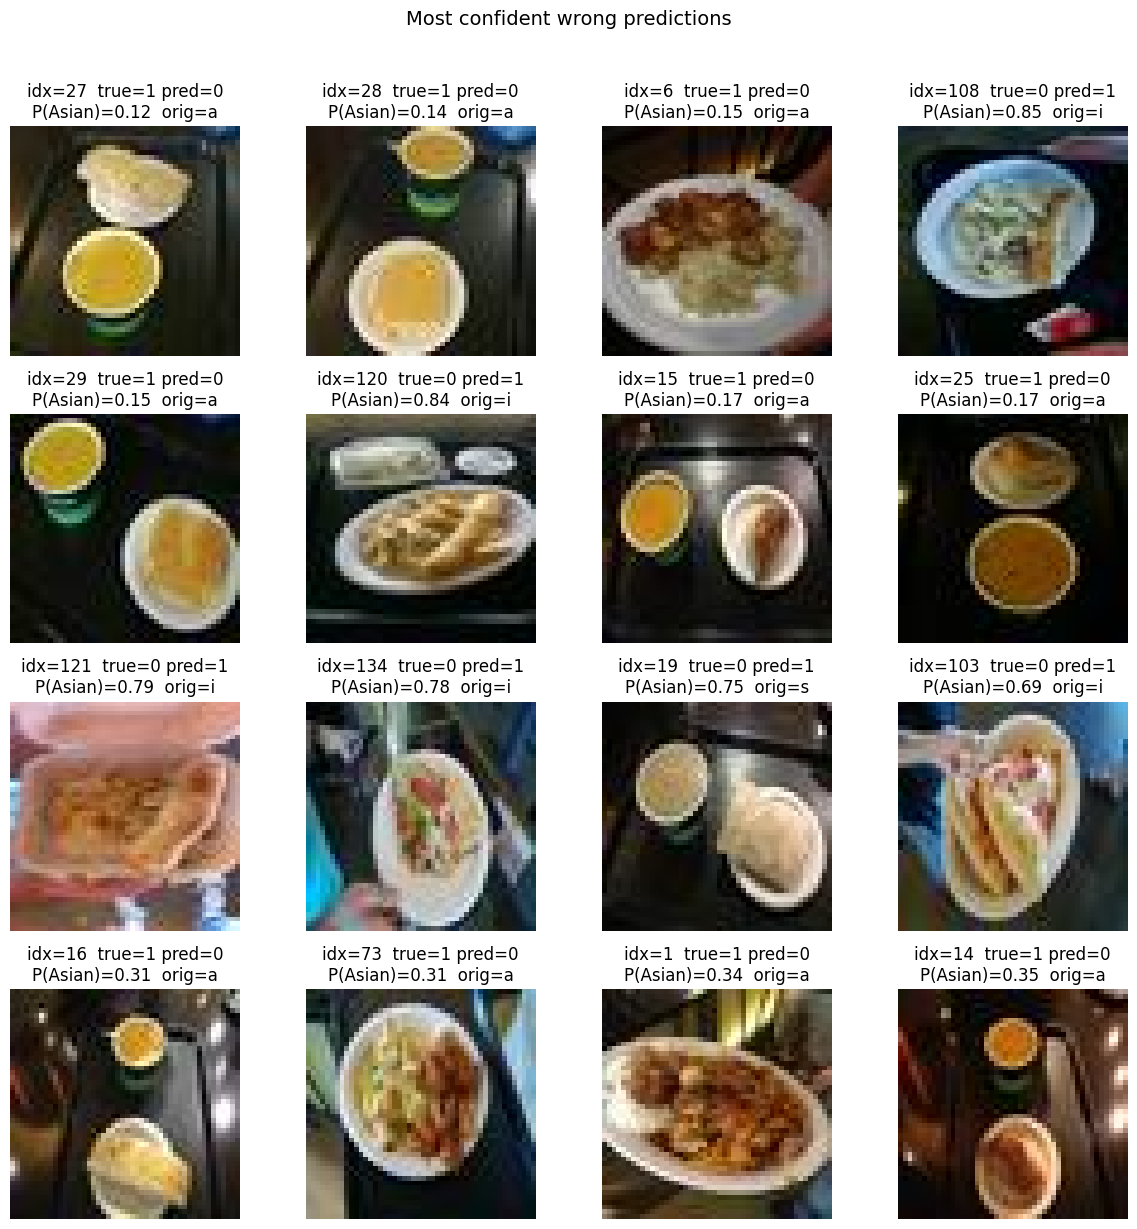

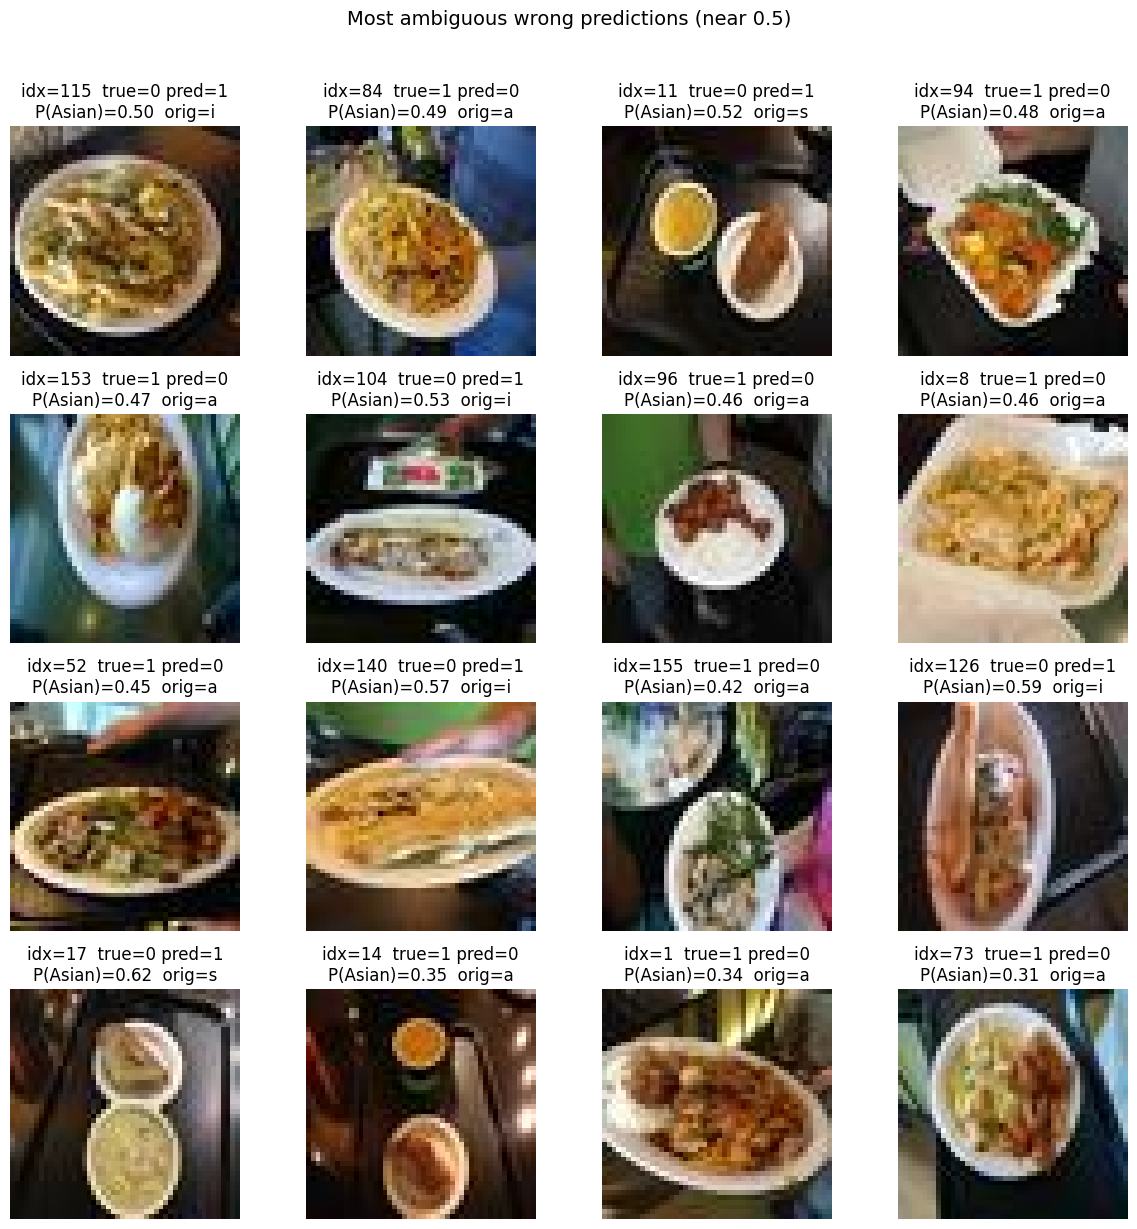

In [3]:
import matplotlib.pyplot as plt

def show_examples(idxs, title, n=16):
    idxs = idxs[:n]
    cols = 4
    rows = int(np.ceil(len(idxs)/cols))
    plt.figure(figsize=(12, 3*rows))
    for k, i in enumerate(idxs):
        true = all_true[i]
        pred = all_pred[i]
        p = all_prob_asian[i]
        plt.subplot(rows, cols, k+1)
        plt.imshow(X_test_raw[i])  # 原始图直接 imshow（作业也提示可以这样做）:contentReference[oaicite:1]{index=1}
        plt.axis("off")
        plt.title(f"idx={i}  true={true} pred={pred}\nP(Asian)={p:.2f}  orig={y_test_raw[i]}")
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# A) 最“自信”错的：|p-0.5| 最大
wrong_conf = np.abs(all_prob_asian[wrong_idx] - 0.5)
conf_order = wrong_idx[np.argsort(-wrong_conf)]
show_examples(conf_order, "Most confident wrong predictions", n=16)

# B) 最“模糊”错的：|p-0.5| 最小（最接近 0.5）
amb_order = wrong_idx[np.argsort(wrong_conf)]
show_examples(amb_order, "Most ambiguous wrong predictions (near 0.5)", n=16)

I examined the test images that my best model misclassified. In the most confident wrong set, many errors are Asian → not Asian with very low P(Asian) (around 0.12–0.17), and these images are often blurry, dark, and dominated by the tray/background, so the food cues are weak. There are also confident not Asian → Asian mistakes (P(Asian) around 0.84–0.85) where the dishes have noodle/pasta-like textures, which can look similar at low resolution. In the most ambiguous wrong set (P(Asian) near 0.5), the foods look visually “in-between,” with similar colors and textures across cuisines. Overall, the model struggles most with low-quality images and foods that look similar across categories, and it may rely too much on background cues.